Importando Bibliotecas

In [1]:
# Bibliotecas para manipulação de dados
import numpy as np  # Suporte para arrays e matemática avançada
import pandas as pd  # Estruturas de dados e ferramentas de análise

# Visualização de dados
import seaborn as sns  # Visualização de dados estatísticos
import matplotlib.pyplot as plt  # Criação de gráficos e visualizações

# PyTorch para construção e treinamento do modelo
import torch  # Biblioteca central para redes neurais e computação tensorial
import torch.nn as nn  # Módulo para construir camadas de rede neural
import torch.optim as optim  # Módulo para otimizadores
from torch.utils.data import DataLoader, TensorDataset  # Utilitários para carregamento de dados e batching

# Sklearn para pré-processamento dos dados
from sklearn.model_selection import train_test_split  # Divisão dos dados em conjuntos de treino e teste
from sklearn.preprocessing import StandardScaler  # Normalização das características


Carregando o Dataset Boston Housing

In [2]:
# URL do dataset
data_url = "http://lib.stat.cmu.edu/datasets/boston"
# Carregar o dataset
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
# Preparar os dados
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Criar um DataFrame do pandas
columns = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]
df = pd.DataFrame(data, columns=columns)
df['MEDV'] = target

print(df)

# CRIM per capita crime rate by town
# ZN proportion of residential land zoned for lots over 25,000 sq.ft.
# INDUS proportion of non-retail business acres per town
# CHAS Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
# NOX nitric oxides concentration (parts per 10 million)
# RM average number of rooms per dwelling
# AGE proportion of owner-occupied units built prior to 1940
# DIS weighted distances to five Boston employment centres
# RAD index of accessibility to radial highways
# TAX full-value property-tax rate per 10,000usd
# PTRATIO pupil-teacher ratio by town
# B 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
# LSTAT % lower status of the population

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0    0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1    0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2    0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3    0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4    0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...    ...   
501  0.06263   0.0  11.93   0.0  0.573  6.593  69.1  2.4786  1.0  273.0   
502  0.04527   0.0  11.93   0.0  0.573  6.120  76.7  2.2875  1.0  273.0   
503  0.06076   0.0  11.93   0.0  0.573  6.976  91.0  2.1675  1.0  273.0   
504  0.10959   0.0  11.93   0.0  0.573  6.794  89.3  2.3889  1.0  273.0   
505  0.04741   0.0  11.93   0.0  0.573  6.030  80.8  2.5050  1.0  273.0   

     PTRATIO       B  LSTAT  MEDV  
0       15.3  396.90   4.98  24.0  
1       17.8  396.90   9.14

Definindo parâmetros que serão alterados constantemente

In [3]:
train_percent = 0.5
val_percent = 0.25
batch = 64
num_layers = 3
layer_sizes = 128
learning_rate = 0.01
dropout = 0.3
epocas = 150

Pré-Processamento dos dados

In [4]:
# Definindo X e Y, com `df['MEDV']` sendo os alvos
X = df.drop('MEDV', axis=1).values
Y = df['MEDV'].values

# Definindo o tamanho dos conjuntos
total_size = len(df)

m_train = int(total_size * train_percent)
m_val = int(total_size * val_percent)
m_test = total_size - (m_train + m_val) #O resto dos dados

# Dividindo os dados em conjuntos de treino, validação e teste
X_train = X[:m_train]
Y_train = Y[:m_train]
X_val = X[m_train:m_train+m_val]
Y_val = Y[m_train:m_train+m_val]
X_test = X[m_train+m_val:]
Y_test = Y[m_train+m_val:]

# Convertendo para tensores PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32).view(-1, 1)  # Redimensionando Y para ter a forma (m, 1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32).view(-1, 1)

# Normalizando os dados de treinamento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_tensor.numpy())  # Fit e transform nos dados de treinamento

# Aplicando a mesma transformação aos conjuntos de validação e teste
X_val_scaled = scaler.transform(X_val_tensor.numpy())
X_test_scaled = scaler.transform(X_test_tensor.numpy())

# Convertendo novamente para tensores PyTorch após a normalização
X_train_norm_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_norm_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_norm_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Criando TensorDatasets e DataLoaders para os conjuntos de treino, validação e teste
train_dataset = TensorDataset(X_train_norm_tensor, Y_train_tensor)
val_dataset = TensorDataset(X_val_norm_tensor, Y_val_tensor)
test_dataset = TensorDataset(X_test_norm_tensor, Y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size = batch, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = batch, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size= batch, shuffle=False)

Definindo o Modelo

In [5]:
class HousePricePredictor(nn.Module):
    def __init__(self, input_features, layer_sizes, dropout):
        super(HousePricePredictor, self).__init__()

        layers = []
        in_features = input_features

        # Verifique se layer_sizes é uma lista de inteiros
        for out_features in layer_sizes:
            layers.append(nn.Linear(in_features, out_features))
            layers.append(nn.LeakyReLU())  # Substituímos nn.tan() por nn.Tanh()
            layers.append(nn.Dropout(dropout))
            in_features = out_features

        layers.append(nn.Linear(in_features, 1))  # Camada de saída
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Criando a instância do modelo, certifique-se de que layer_sizes seja uma lista de inteiros
layer_sizes = [64, 32, 16]  # Exemplo de tamanhos das camadas
model = HousePricePredictor(input_features=13, layer_sizes=layer_sizes, dropout=dropout)

# Definindo o critério de perda como Mean Squared Error Loss
criterio = nn.MSELoss()

# Definindo o otimizador como Adam, com a taxa de aprendizado especificada
otimizador = torch.optim.Adam(model.parameters(), lr=learning_rate)  # Ajuste a taxa de aprendizado se necessário



Treinando o Modelo

In [6]:
custo = []  # Para armazenar a perda de treinamento média por época
custo_val = []  # Para armazenar a perda de validação média por época
for epoch in range(epocas):
    model.train()  # Coloca o modelo em modo de treinamento
    train_loss = 0.0

    for inputs, targets in train_loader:
        otimizador.zero_grad()
        outputs = model(inputs)
        loss = criterio(outputs, targets)
        loss.backward()
        otimizador.step()
        train_loss += loss.item() * inputs.size(0)  # Multiplica pela quantidade no batch para acumular corretamente

    # Validação
    model.eval()  # Coloca o modelo em modo de avaliação
    val_loss = 0.0
    with torch.no_grad():  # Desabilita o cálculo de gradientes para economia de memória e computação
        for inputs, targets in val_loader:
            outputs = model(inputs)
            loss = criterio(outputs, targets)
            val_loss += loss.item() * inputs.size(0)

    # Calcula a média das perdas
    train_loss = train_loss / len(train_loader.dataset)
    val_loss = val_loss / len(val_loader.dataset)
    custo.append(train_loss)
    custo_val.append(val_loss)

    # Imprime as estatísticas de treinamento e validação
    print(f'Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}')

Epoch 1: Train Loss: 652.5643, Validation Loss: 729.8758
Epoch 2: Train Loss: 558.9702, Validation Loss: 481.6919
Epoch 3: Train Loss: 318.4830, Validation Loss: 193.3502
Epoch 4: Train Loss: 135.0389, Validation Loss: 606.8119
Epoch 5: Train Loss: 178.2608, Validation Loss: 211.6299
Epoch 6: Train Loss: 69.0225, Validation Loss: 169.5369
Epoch 7: Train Loss: 108.3126, Validation Loss: 176.2463
Epoch 8: Train Loss: 82.1575, Validation Loss: 271.7768
Epoch 9: Train Loss: 62.7403, Validation Loss: 397.4204
Epoch 10: Train Loss: 71.3820, Validation Loss: 320.4275
Epoch 11: Train Loss: 71.8164, Validation Loss: 210.3739
Epoch 12: Train Loss: 66.1903, Validation Loss: 211.6198
Epoch 13: Train Loss: 67.0835, Validation Loss: 253.0339
Epoch 14: Train Loss: 66.9313, Validation Loss: 380.2930
Epoch 15: Train Loss: 82.8571, Validation Loss: 352.0386
Epoch 16: Train Loss: 65.4352, Validation Loss: 263.0595
Epoch 17: Train Loss: 66.4360, Validation Loss: 216.7916
Epoch 18: Train Loss: 62.2721, Val

Plotando o gráfico das perdas

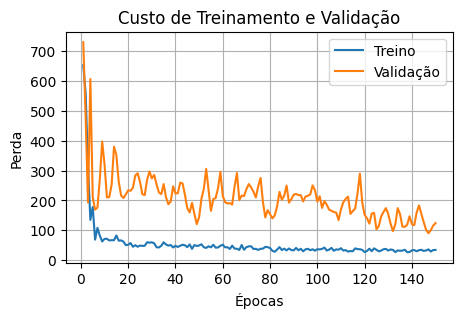

In [7]:
epocas = range(1, len(custo) + 1)

plt.figure(figsize=(5, 3))  # Ajusta o tamanho da figura
plt.plot(epocas, custo, label='Treino')
plt.plot(epocas, custo_val, label='Validação')
plt.title('Custo de Treinamento e Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.grid(True)
plt.show()

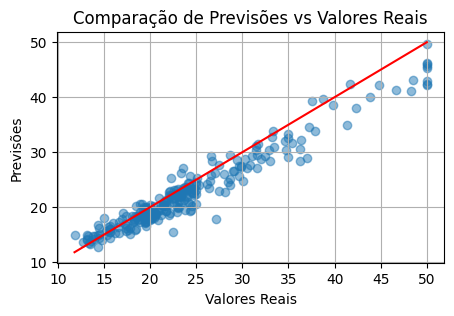

In [8]:
model.eval()  # Coloca o modelo em modo de avaliação
predictions_train = []
real_values_train = []

with torch.no_grad():  # Desativa o cálculo de gradientes
    for inputs, targets in train_loader:
        outputs = model(inputs)
        predictions_train.extend(outputs.view(-1).tolist())
        real_values_train.extend(targets.view(-1).tolist())

# Plotando em um gráfico de dispersão
plt.figure(figsize=(5, 3))
plt.scatter(real_values_train, predictions_train, alpha=0.5)
plt.title('Comparação de Previsões vs Valores Reais')
plt.xlabel('Valores Reais')
plt.ylabel('Previsões')
plt.plot([min(real_values_train), max(real_values_train)], [min(real_values_train), max(real_values_train)], 'r')  # Linha de perfeita correspondência
plt.grid(True)
plt.show()

Avaliação com o conjunto de testes

In [9]:
model.eval()  # Coloca o modelo em modo de avaliação
test_loss = 0.0
with torch.no_grad():  # Desativa o cálculo de gradientes
    for inputs, targets in test_loader:
        outputs = model(inputs)
        loss = criterio(outputs, targets)
        test_loss += loss.item() * inputs.size(0)

test_loss /= len(test_loader.dataset)
print(f'Test Loss: {test_loss:.4f}')

Test Loss: 2349.0389


Comparando os valores previstos com os valores reais

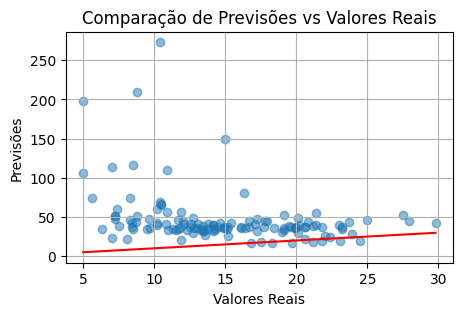

In [10]:
model.eval()  # Coloca o modelo em modo de avaliação
predictions = []
real_values = []

with torch.no_grad():  # Desativa o cálculo de gradientes
    for inputs, targets in test_loader:
        outputs = model(inputs)
        predictions.extend(outputs.view(-1).tolist())
        real_values.extend(targets.view(-1).tolist())

# Plotando em um gráfico de dispersão
plt.figure(figsize=(5, 3))
plt.scatter(real_values, predictions, alpha=0.5)
plt.title('Comparação de Previsões vs Valores Reais')
plt.xlabel('Valores Reais')
plt.ylabel('Previsões')
plt.plot([min(real_values), max(real_values)], [min(real_values), max(real_values)], 'r')  # Linha de perfeita correspondência
plt.grid(True)
plt.show()